In [16]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

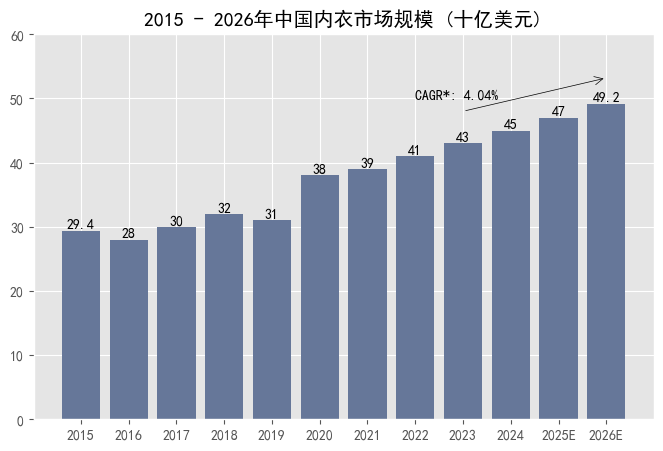

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

# 年份数据
years = np.arange(2015, 2027)
# 模拟的市场规模数据（十亿美 元，大体趋势贴近，数值可微调）
market_size = [29.4, 28, 30, 32, 31, 38, 39, 41, 43, 45, 47, 49.2]
# 年份标签，处理 2025E、2026E
year_labels = [str(year) if year < 2025 else f"{year}E" for year in years]

# 创建画布
fig, ax = plt.subplots(figsize=(8, 5))

# 绘制柱状图
bars = ax.bar(years, market_size, color='#667799', width=0.8)

# 在柱子上标注数值
for bar, value in zip(bars, market_size):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value}',
            ha='center', va='bottom')

# 标注 CAGR
ax.text(2022, 50, f'CAGR*: 4.04%', ha='left')

# 绘制30度斜向上的箭头
x_start = 2023
y_start = 48
# 计算30度角的终点坐标（dx = 3，dy = 3 * tan(30°)）
angle_rad = np.radians(60)
dx = 3
dy = dx * np.tan(angle_rad)
x_end = x_start + dx
y_end = y_start + dy

# 使用FancyArrowPatch绘制30度斜向箭头
arrow = FancyArrowPatch((x_start, y_start), (x_end, y_end), 
                        arrowstyle='->', 
                        connectionstyle='arc3,rad=0', 
                        color='black', 
                        mutation_scale=15)
ax.add_patch(arrow)

# 设置 x 轴刻度
ax.set_xticks(years)
ax.set_xticklabels(year_labels)

# 设置 y 轴范围
ax.set_ylim(0, 60)

# 设置图表标题
ax.set_title('2015 - 2026年中国内衣市场规模 (十亿美元)')

# 显示图表
plt.show()    

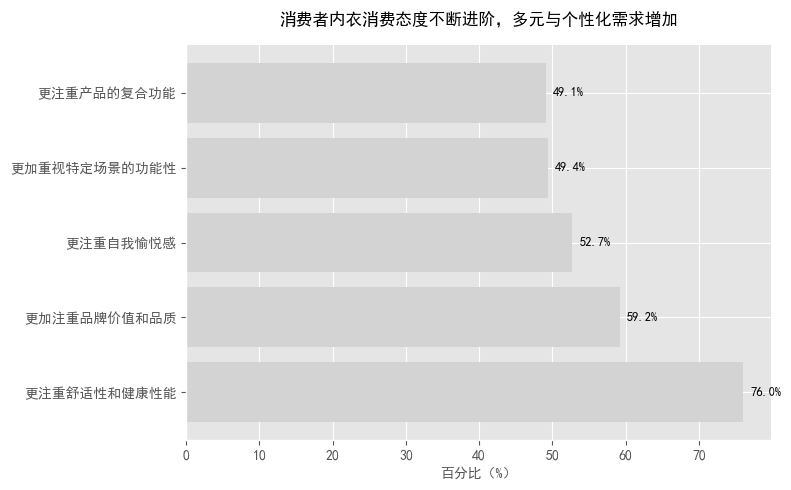

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 数据（类别、对应百分比，大体接近原数据即可）
labels = ["更注重舒适性和健康性能", "更加注重品牌价值和品质", "更注重自我愉悦感", 
          "更加重视特定场景的功能性", "更注重产品的复合功能"]
percentages = [76.0, 59.2, 52.7, 49.4, 49.1]

# 为每个条形设置位置（横向条形图用 y 轴坐标）
y_pos = np.arange(len(labels))  

# 创建画布和轴对象
fig, ax = plt.subplots(figsize=(8, 5))  # 可调整尺寸适配原图表比例

# 绘制横向条形图，颜色选接近原图表的浅色调，这里用 #D3D3D3 类似灰色系（可根据实际微调）
ax.barh(y_pos, percentages, color='#D3D3D3')  

# 设置 y 轴刻度和标签，让类别显示在左侧
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)

# 设置 x 轴标签（百分比），并调整字体等样式让其更贴近原图表风格
ax.set_xlabel('百分比（%）', fontsize=10)  

# 添加数据标签，在每个条形右侧显示百分比数值
for i, v in enumerate(percentages):
    ax.text(v + 1, i, f'{v}%', va='center', fontsize=9)  

# 隐藏顶部和右侧边框，更贴近原图表简洁风格
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置标题（与原图表标题一致）
ax.set_title('消费者内衣消费态度不断进阶，多元与个性化需求增加', fontsize=12, pad=15)  

# 调整布局，避免标签挤压
plt.tight_layout()  

# 显示图表
plt.show()

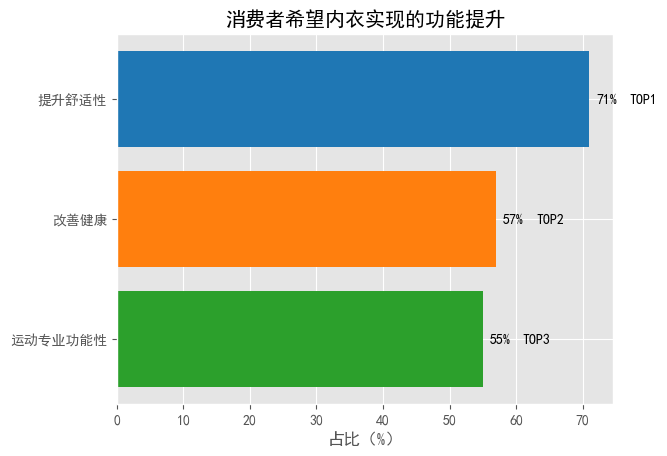

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 功能提升项
features = ["提升舒适性", "改善健康", "运动专业功能性"]
# 对应占比数据
percentages = [71, 57, 55]
# 用于在图表上显示 TOP 信息，这里根据索引对应设置
tops = ["TOP1", "TOP2", "TOP3"]

# 设置字体，确保中文显示正常（需根据自己环境调整字体路径或名称，这里以 SimHei 为例，若没有可替换为其他支持中文的字体）
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

y_pos = np.arange(len(features))  # y 轴位置

# 创建横向条形图
fig, ax = plt.subplots()
bars = ax.barh(y_pos, percentages, align='center', color=['#1f77b4', '#ff7f0e', '#2ca02c'])  # 设置颜色，尽量接近示例风格

# 在每个条形末端添加占比数值
for bar, percentage in zip(bars, percentages):
    length = bar.get_width()
    ax.text(length + 1,  # 数值显示位置的 x 坐标，可微调
            bar.get_y() + bar.get_height() / 2,  # 数值显示位置的 y 坐标，居中
            f'{percentage}%',
            va='center')

# 在每个条形右侧添加 TOP 信息
for i, (bar, top) in enumerate(zip(bars, tops)):
    length = bar.get_width()
    ax.text(length + 6,  # 可根据实际情况微调位置
            bar.get_y() + bar.get_height() / 2,
            top,
            va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.invert_yaxis()  # 让第一个功能项显示在最上方
ax.set_xlabel('占比（%）')
ax.set_title('消费者希望内衣实现的功能提升')

plt.show()

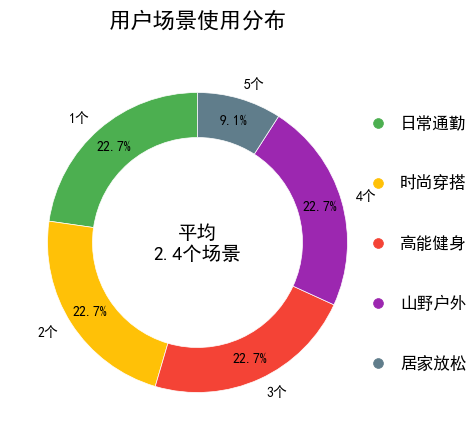

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
data = [1, 1, 1, 1, 0.4]  # 模拟各区间占比，总和对应平均 2.4 场景，可根据实际微调
labels = ["1个", "2个", "3个", "4个", "5个"]
colors = ["#4CAF50", "#FFC107", "#F44336", "#9C27B0", "#607D8B"]  # 模拟接近的颜色

# 绘制环形图（甜甜圈图）
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    data,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",  # 显示百分比
    startangle=90,
    pctdistance=0.85,  # 百分比标签距离圆心的距离
    wedgeprops={"width": 0.3, "edgecolor": "white"}  # 设置环形宽度和边缘颜色
)

# 添加中心文本，显示平均场景数
ax.text(
    0,
    0,
    "平均\n2.4个场景",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

# 右侧添加带颜色的图例说明
text_descriptions = [
    "日常通勤",
    "时尚穿搭",
    "高能健身",
    "山野户外",
    "居家放松"
]

# 计算文本显示的纵坐标，让文本均匀分布
y_positions = np.linspace(0.8, -0.8, len(text_descriptions))
for i, (desc, color) in enumerate(zip(text_descriptions, colors)):
    # 添加颜色标记
    ax.scatter(
        1.2,  # x位置（略左移，为标记腾出空间）
        y_positions[i],
        s=50,  # 标记大小
        color=color,  # 使用对应的颜色
        zorder=3  # 确保标记显示在最上层
    )
    # 添加文本说明
    ax.text(
        1.35,  # 文本起始位置（右移以避免重叠）
        y_positions[i],
        desc,
        fontsize=12,
        ha="left",
        va="center"
    )

# 添加标题
plt.title("用户场景使用分布", fontsize=16, fontweight="bold", pad=20)

# 调整布局，避免元素重叠（略微扩大右侧空间）
plt.subplots_adjust(right=0.75, top=0.85)

# 显示图表
plt.show()    

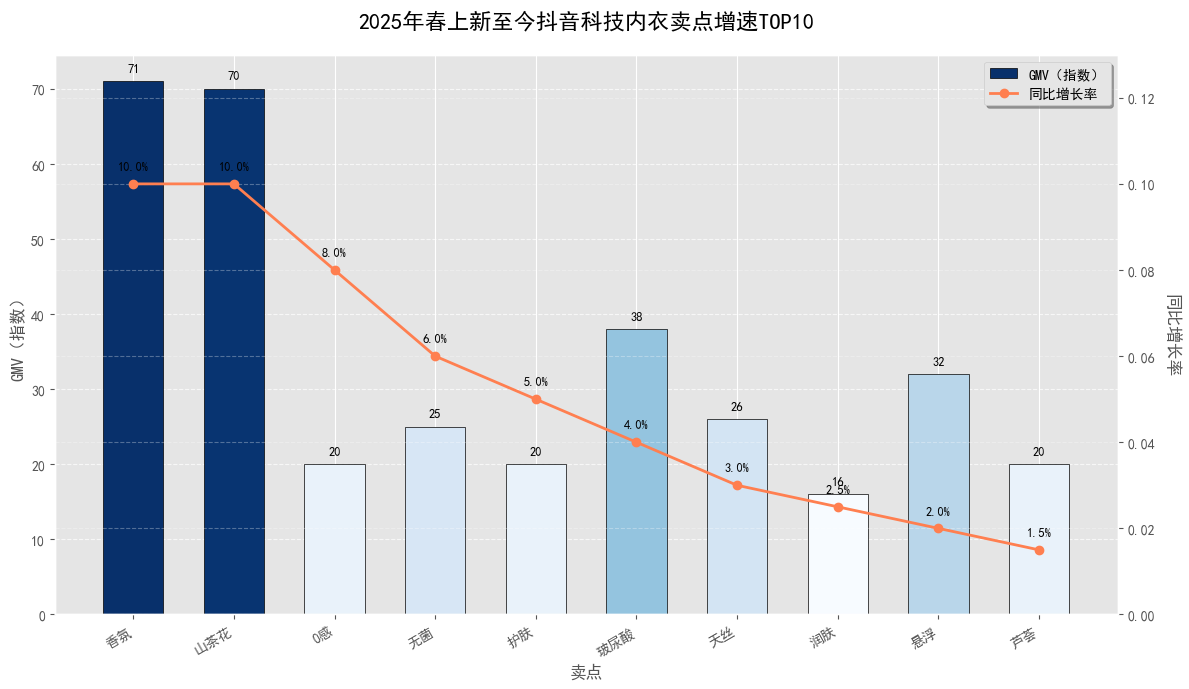

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 模拟数据，大体对应原图表的类别和趋势
categories = ["香氛", "山茶花", "0感", "无菌", "护肤", "玻尿酸", "天丝", "润肤", "悬浮", "芦荟"]
gmv_data = [71, 70, 20, 25, 20, 38, 26, 16, 32, 20]  # GMV（指数）模拟数据
growth_data = [0.10, 0.1, 0.08, 0.06, 0.05, 0.04, 0.03, 0.025, 0.02, 0.015]  # 同比模拟数据

x = np.arange(len(categories))  # x轴位置

# 创建画布和子图，设置图表大小
fig, ax1 = plt.subplots(figsize=(12, 7))

# 设置背景风格 - 使用Matplotlib内置样式替代
plt.style.use('ggplot')

# 绘制柱状图（GMV） - 使用渐变色
cmap = plt.cm.Blues
norm = plt.Normalize(min(gmv_data), max(gmv_data))
colors = cmap(norm(gmv_data))

bars = ax1.bar(x, gmv_data, width=0.6, color=colors, label='GMV（指数）', edgecolor='black', linewidth=0.5)
ax1.set_ylabel('GMV（指数）', fontsize=12, fontweight='bold')
ax1.set_xlabel('卖点', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=30, ha='right', fontsize=10)  # 旋转x轴标签

# 添加柱状图数据标签
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height}', ha='center', va='bottom', fontsize=9)

# 创建第二个y轴绘制折线图（同比）
ax2 = ax1.twinx()
line, = ax2.plot(x, growth_data, color='#FF7F50', marker='o', markersize=6, 
                linewidth=2, label='同比增长率')
ax2.set_ylabel('同比增长率', rotation=270, labelpad=18, fontsize=12, fontweight='bold')
ax2.set_ylim(0, 0.13)  # 大致对应原图表百分比范围

# 添加折线图数据标签
for i, txt in enumerate(growth_data):
    ax2.annotate(f'{txt:.1%}', (x[i], growth_data[i]), 
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center',
                fontsize=9)

# 添加标题和图例
plt.title('2025年春上新至今抖音科技内衣卖点增速TOP10', fontsize=16, fontweight='bold', pad=20)

# 合并两个图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True, shadow=True)

# 添加网格线
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# 调整图表边距
plt.tight_layout()

# 显示图表
plt.show()